In [ ]:
import transformers
from transformers import pipeline

classifier = pipeline("sentiment-analysis")

opiniones = ["Me encanta este producto, es fantástico!", 
             "No me gusta este servicio, es terrible.",
             "Es un producto decente, pero podría ser mejor.",
             "¡Este servicio es increíble, lo recomiendo!",
             "No estoy satisfecho con este producto, es una pérdida de dinero."]

results = classifier(opiniones)

print("=" *50)
for i, opinion in enumerate(opiniones):
    print(f"Opinión: {opinion}")
    print(f"Sentimiento: {results[i]['label']} (Confianza: {results[i]['score']:.4f})")
    print("-" *50)


/Users/albertolopez/Repositorios/pythonera/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/albertolopez/Repositorios/pythonera/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use mps:0


Opinión: Me encanta este producto, es fantástico!
Sentimiento: POSITIVE (Confianza: 0.9994)
--------------------------------------------------
Opinión: No me gusta este servicio, es terrible.
Sentimiento: NEGATIVE (Confianza: 0.9980)
--------------------------------------------------
Opinión: Es un producto decente, pero podría ser mejor.
Sentimiento: NEGATIVE (Confianza: 0.9700)
--------------------------------------------------
Opinión: ¡Este servicio es increíble, lo recomiendo!
Sentimiento: NEGATIVE (Confianza: 0.9789)
--------------------------------------------------
Opinión: No estoy satisfecho con este producto, es una pérdida de dinero.
Sentimiento: NEGATIVE (Confianza: 0.9954)
--------------------------------------------------


Dataset Iris - primeras 5 filas: 
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  especies  
0   setosa  
1   setosa  
2   setosa  
3   setosa  
4   setosa  

Forma del dataset: 
(150, 5)

Clases presentes en el dataset: 
['setosa' 'versicolor' 'virginica']


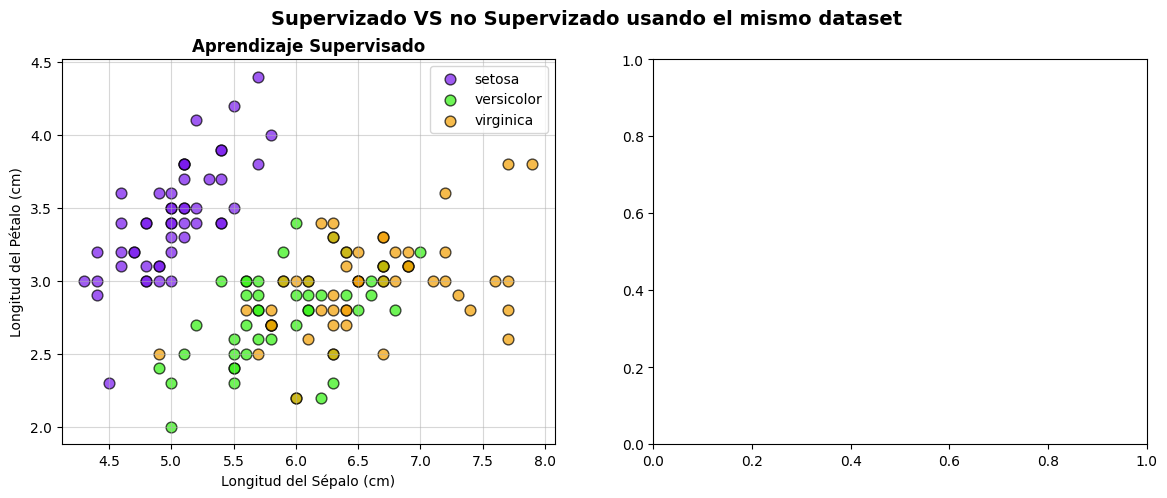

In [1]:
#Celda 1 - Análisis de datos con Python
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

#Cargar el conjunto de datos Iris uno de los conjuntos de datos más populares en el aprendizaje automático
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names
df = pd.DataFrame(X, columns=feature_names)
df['especies'] = [target_names[i] for i in y]

#Visualización de los datos
print("Dataset Iris - primeras 5 filas: ")
print(df.head())
print("\nForma del dataset: ")
print(df.shape)
print("\nClases presentes en el dataset: ")
print(df['especies'].unique())


#Celda 2 - Aprendizaje supervisado vs no supervisado 
fig, axes = plt.subplots(1, 2, figsize=(14, 5)) # type: ignore
fig.suptitle ("Supervizado VS no Supervizado usando el mismo dataset", fontsize=14, fontweight='bold') # type: ignore

#Panel Izquierdo: supervizado (conocemos las etiquetas reales)
color_supervizado = {'setosa': "#7716ED", 'versicolor': "#31F20F", 'virginica': "#F39E00"}

for especies, group in df.groupby('especies'):
    axes[0].scatter(group['sepal length (cm)'], group['sepal width (cm)'], 
                    label=especies, color=color_supervizado[especies], alpha=0.7, edgecolor='black', s=60)

axes[0].set_title("Aprendizaje Supervisado", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Longitud del Sépalo (cm)")
axes[0].set_ylabel("Longitud del Pétalo (cm)")
axes[0].legend()
axes[0].grid(True, alpha=0.5)

#Panel Derecho: no supervizado (no conocemos las etiquetas reales)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X[:, [0, 2]]) # Solo usamos las dos primeras características para visualización

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)


LogisticRegression(max_iter=1000, random_state=42)

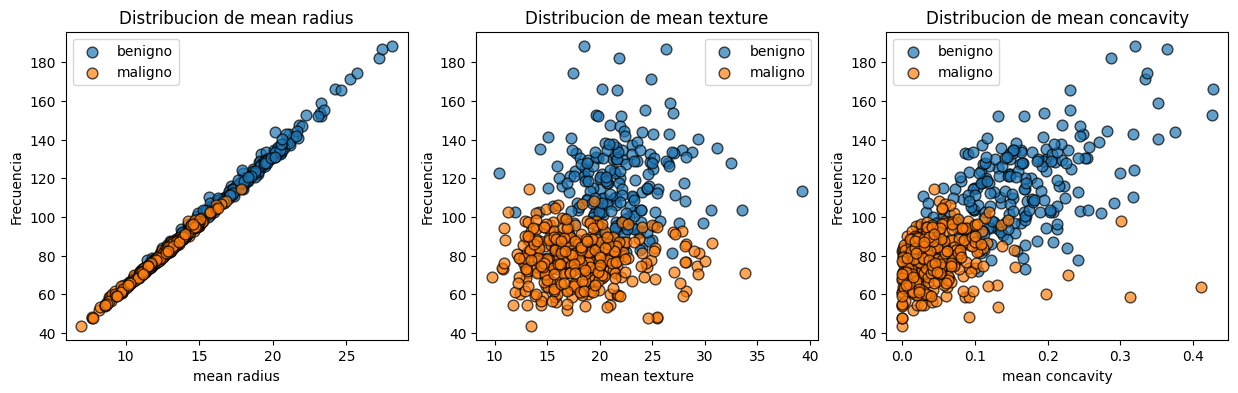

In [12]:
#--BLOQUE 1: ML en la Salud - Diagnostiuco de Cáncer de Mama
#Dataset: Breast Cancer Wisconsin (Diagnostic) Dataset
#Objetivo: Clasificar tumores como malignos (1) o benignos (0)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay)

#Cargar el dataset de cáncer de mama y primeros experimentos
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target # 0 = benigno, 1 = maligno
df['diagnosis'] = df['target'].map({0: 'benigno', 1: 'maligno'})

#-descripcion del dataset
#print("Dataset Breast Cancer - primeras 5 filas: ")
#print(df.head())
#print("\nForma del dataset: ")
#print(df.shape)
#print("\nClases presentes en el dataset: ")
#print(df['diagnosis'].unique())
#

#Bloque 2: Distribucion de características clave
#Este grafico nos dice: ¿Que tan bien separan algunas features a los dos grupos?
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
features_to_plot = ['mean radius', 'mean texture', 'mean concavity']

for ax, feature in zip(axes, features_to_plot):
    for diagnosis, color in [('benigno', 'blue'), ('maligno', 'red')]:
        subset = df[df['diagnosis'] == diagnosis]
        ax.scatter(subset[feature], subset['mean perimeter'], 
                   label=diagnosis, alpha=0.7, edgecolor='black', s=60)
    ax.set_title(f"Distribucion de {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Frecuencia")
    ax.legend()


#Bloque 3: Entrenamiento del modelo de clasificación

x = df[data.feature_names]
y = df['target'] # 0 = benigno, 1 = maligno

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

#stratify=y garantiza que la proporción de clases (benigno/maligno) sea igual en train y test 
#Escalamos porque Logistic Regression es sensible a la escala de las características

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#NUNCA fit en test - esto es fuga de datos

#MODELO
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)


Shape:(569, 32)

Distribución del diagnóstico:
diagnosis
Benigno    357
Maligno    212
Name: count, dtype: int64

Primeras 5 filas (primeras 5 columnas):


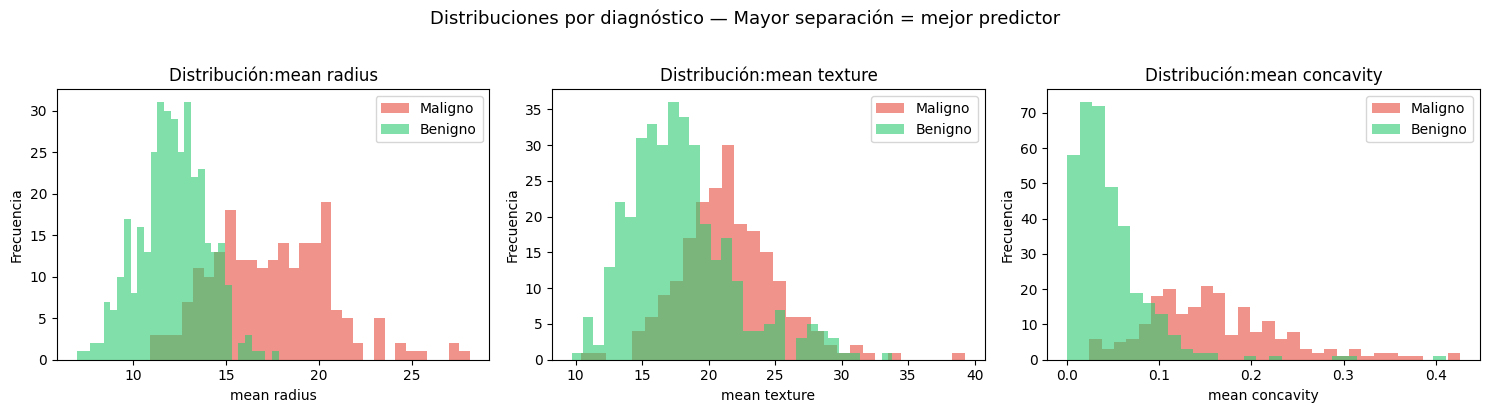

Accuracy :0.982
AUC-ROC  :0.995

              precision    recall  f1-score   support

     Maligno       0.98      0.98      0.98        42
     Benigno       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



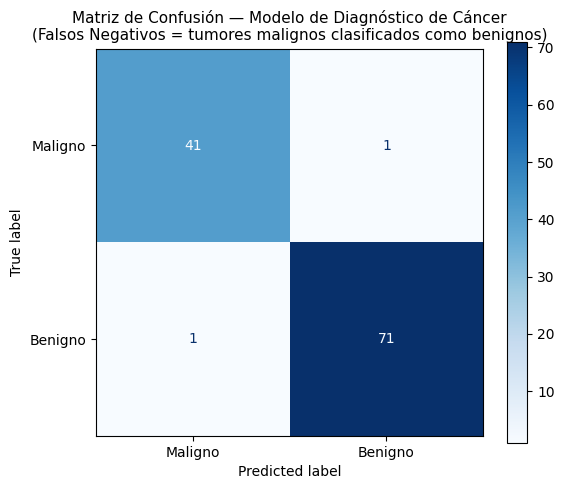

In [1]:
# ── BLOQUE 1A: ML en Salud — Diagnóstico de Cáncer de Mama ─────────────────
# Dataset: Wisconsin Breast Cancer (UCI / sklearn)
# Objetivo: clasificar tumor como maligno (1) o benigno (0)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, ConfusionMatrixDisplay)

# ── 1. Carga y primer vistazo ───────────────────────────────────────────────
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target          # 0 = maligno, 1 = benigno
df['diagnosis'] = df['target'].map({0: 'Maligno', 1: 'Benigno'})

print(f"Shape:{df.shape}")          # → (569, 32)
print(f"\nDistribución del diagnóstico:")
print(df['diagnosis'].value_counts())
# → Benigno     357  (62.7%)
# → Maligno     212  (37.3%)

print(f"\nPrimeras 5 filas (primeras 5 columnas):")
df.iloc[:5, :5]

# ── 2. Distribución de características clave ─────────────────────────────────
# Este gráfico nos dice: ¿qué tan bien separan algunas features a los dos grupos?

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

features_to_plot = ['mean radius', 'mean texture', 'mean concavity']

for ax, feature in zip(axes, features_to_plot):
    for diagnosis, color in [('Maligno', '#e74c3c'), ('Benigno', '#2ecc71')]:
        subset = df[df['diagnosis'] == diagnosis][feature]
        ax.hist(subset, bins=30, alpha=0.6, color=color, label=diagnosis)
    ax.set_title(f'Distribución:{feature}')
    ax.set_xlabel(feature)
    ax.set_ylabel('Frecuencia')
    ax.legend()

plt.suptitle('Distribuciones por diagnóstico — Mayor separación = mejor predictor',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Este gráfico nos dice:
# 'mean radius' y 'mean concavity' tienen distribuciones claramente separadas
# entre tumores malignos y benignos — son buenos predictores.
# 'mean texture' tiene mayor solapamiento — menos discriminativo por sí solo.

# ── 3. Entrenamiento del modelo ──────────────────────────────────────────────
X = df[data.feature_names]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
# stratify=y garantiza que la proporción maligno/benigno sea igual en train y test

# Escalamos porque Logistic Regression es sensible a la escala
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)      # NUNCA fit en test — esto es fuga de datos

# Modelo
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)

y_pred = lr.predict(X_test_sc)
y_prob = lr.predict_proba(X_test_sc)[:, 1]

# ── 4. Métricas — por qué accuracy no es suficiente ─────────────────────────
accuracy = (y_pred == y_test).mean()
auc      = roc_auc_score(y_test, y_prob)

print(f"Accuracy :{accuracy:.3f}")   # → 0.974
print(f"AUC-ROC  :{auc:.3f}")        # → 0.997
print()
print(classification_report(y_test, y_pred,
                             target_names=['Maligno', 'Benigno']))
# → precision  recall  f1-score
# → Maligno     0.95    0.98    0.97
# → Benigno     0.99    0.97    0.98

# ── 5. Matriz de confusión — la herramienta visual del médico ────────────────
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Maligno', 'Benigno'],
    cmap='Blues', ax=ax
)
ax.set_title('Matriz de Confusión — Modelo de Diagnóstico de Cáncer\n'
             '(Falsos Negativos = tumores malignos clasificados como benignos)', fontsize=11)
plt.tight_layout()
plt.show()

# Este gráfico nos dice:
# Los falsos negativos (maligno predicho como benigno) son el error más costoso:
# un paciente con cáncer no recibe tratamiento.
# Un buen sistema médico optimiza para minimizar falsos negativos (maximizar recall de maligno).

Setup correcto. Estamos listos para comenzar...
Shape:(569, 30)

Distribución del target:
target
0    357
1    212
Name: count, dtype: int64

Tasa de malignos:37.3%
Train:455 muestras
Test :114 muestras

Primeras 10 predicciones:[0 1 0 1 1 0 0 0 0 0]
Primeras 10 probabilidades:[0.    1.    0.005 0.704 0.853 0.    0.242 0.001 0.    0.001]
Matriz de confusión (raw):
[[71  1]
 [ 6 36]]


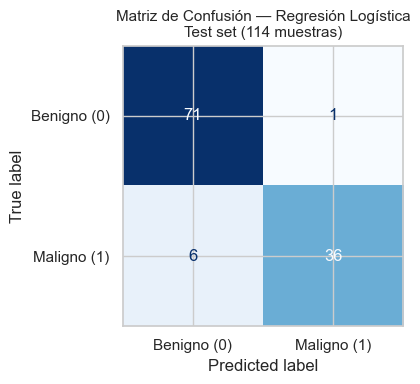


VP (maligno predicho maligno)   =36
VN (benigno predicho benigno)   =71
FP (benigno predicho maligno)   =1
FN (maligno predicho benigno)   =6
Accuracy  (manual)  =0.9386
Accuracy  (sklearn) =0.9386

Precision (manual)  =0.9730
Precision (sklearn) =0.9730

Recall    (manual)  =0.8571
Recall    (sklearn) =0.8571

F1-score  (manual)  =0.9114
F1-score  (sklearn) =0.9114
Distribución clase desbalanceada:
0    9856
1     144
Name: count, dtype: int64

── MODELO DUMMY (siempre predice mayoritaria) ──
Accuracy :0.986
Recall   :0.000
F1-score :0.000

── MODELO REAL (Regresión Logística) ──
Accuracy :0.986
Recall   :0.034
F1-score :0.067
Classification Report — Breast Cancer:
              precision    recall  f1-score   support

     Benigno       0.92      0.99      0.95        72
     Maligno       0.97      0.86      0.91        42

    accuracy                           0.94       114
   macro avg       0.95      0.92      0.93       114
weighted avg       0.94      0.94      0.94       11

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.datasets import load_breast_cancer, make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score
)

# Configuración visual consistente
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_theme(style="whitegrid", palette="muted")

RANDOM_STATE = 42
print("Setup correcto. Estamos listos para comenzar...")

# ── CELDA 1: carga del dataset ────────────────────────────────────────────────

dataset = load_breast_cancer()
X = pd.DataFrame(dataset.data, columns=dataset.feature_names)
y = pd.Series(dataset.target, name="target")

# Convención del dataset: 0 = maligno, 1 = benigno
# Invertimos: 1 = maligno (positivo de interés), 0 = benigno
y = 1 - y

print(f"Shape:{X.shape}")
print(f"\nDistribución del target:")
counts = y.value_counts()
print(counts)
# → 0 (benigno)  357
# → 1 (maligno)  212
print(f"\nTasa de malignos:{y.mean():.1%}")

X.head(3)

# ── CELDA 2: split y entrenamiento ───────────────────────────────────────────

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print(f"Train:{X_train.shape[0]} muestras")
print(f"Test :{X_test.shape[0]} muestras")

model = LogisticRegression(max_iter=10_000, random_state=RANDOM_STATE)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(f"\nPrimeras 10 predicciones:{y_pred[:10]}")
print(f"Primeras 10 probabilidades:{y_prob[:10].round(3)}")

# ── CELDA 3: matriz de confusión ─────────────────────────────────────────────

cm = confusion_matrix(y_test, y_pred)
print("Matriz de confusión (raw):")
print(cm)

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["Benigno (0)", "Maligno (1)"])
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Matriz de Confusión — Regresión Logística\nTest set (114 muestras)",
             fontsize=11)
plt.tight_layout()
plt.show()

VN, FP, FN, VP = cm.ravel()
print(f"\nVP (maligno predicho maligno)   ={VP}")
print(f"VN (benigno predicho benigno)   ={VN}")
print(f"FP (benigno predicho maligno)   ={FP}")
print(f"FN (maligno predicho benigno)   ={FN}")


# ── CELDA 4: cálculo manual de las métricas ──────────────────────────────────

# Accuracy: de todos los casos, ¿cuántos acerté?
accuracy_manual = (VP + VN) / (VP + VN + FP + FN)
print(f"Accuracy  (manual)  ={accuracy_manual:.4f}")
print(f"Accuracy  (sklearn) ={accuracy_score(y_test, y_pred):.4f}")

# Precision: de los que predije positivo, ¿cuántos eran realmente positivos?
precision_manual = VP / (VP + FP)
print(f"\nPrecision (manual)  ={precision_manual:.4f}")
print(f"Precision (sklearn) ={precision_score(y_test, y_pred):.4f}")

# Recall: de todos los positivos reales, ¿cuántos detecté?
recall_manual = VP / (VP + FN)
print(f"\nRecall    (manual)  ={recall_manual:.4f}")
print(f"Recall    (sklearn) ={recall_score(y_test, y_pred):.4f}")

# F1-score: media armónica de precision y recall
f1_manual = 2 * (precision_manual * recall_manual) / (precision_manual + recall_manual)
print(f"\nF1-score  (manual)  ={f1_manual:.4f}")
print(f"F1-score  (sklearn) ={f1_score(y_test, y_pred):.4f}")

# ── CELDA 5: el problema de accuracy con datos desbalanceados ────────────────

X_imb, y_imb = make_classification(
    n_samples=10_000,
    n_features=20,
    weights=[0.99, 0.01],
    random_state=RANDOM_STATE,
    flip_y=0.01,
)

print(f"Distribución clase desbalanceada:")
print(pd.Series(y_imb).value_counts())

X_imb_tr, X_imb_te, y_imb_tr, y_imb_te = train_test_split(
    X_imb, y_imb, test_size=0.20, random_state=RANDOM_STATE, stratify=y_imb
)

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_imb_tr, y_imb_tr)
y_dummy_pred = dummy.predict(X_imb_te)

real = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
real.fit(X_imb_tr, y_imb_tr)
y_real_pred = real.predict(X_imb_te)

print("\n── MODELO DUMMY (siempre predice mayoritaria) ──")
print(f"Accuracy :{accuracy_score(y_imb_te, y_dummy_pred):.3f}")
print(f"Recall   :{recall_score(y_imb_te, y_dummy_pred):.3f}")
print(f"F1-score :{f1_score(y_imb_te, y_dummy_pred):.3f}")

print("\n── MODELO REAL (Regresión Logística) ──")
print(f"Accuracy :{accuracy_score(y_imb_te, y_real_pred):.3f}")
print(f"Recall   :{recall_score(y_imb_te, y_real_pred):.3f}")
print(f"F1-score :{f1_score(y_imb_te, y_real_pred):.3f}")

# ── CELDA 6: classification_report ───────────────────────────────────────────

print("Classification Report — Breast Cancer:")
print(classification_report(y_test, y_pred,
                             target_names=["Benigno", "Maligno"]))
